# K-Nearest Neighbors Classifier with SMOTE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import randint
import warnings
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')
from scipy.stats import randint
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import pickle
from sklearn.model_selection import cross_val_score

# EDA

## Definición del problema.

> Entrenar un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas para ayudar al cliente a elegir un vino digno de sommelier.

## Recopilación de datos.
> Dataset de [Wine Quality Data Set - UCI](https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv)

In [2]:
df = pd.read_csv("/workspaces/CarlosRestrepo-machine-learning-python/data/raw/winequality-red.csv", sep=';')

## Analisis descriptivo.

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


#### Observaciones:
> - El data frame se compone de 1559 filas y 12 columnas de tipo float64(11) y  int64(1).
> - No hay valores nulos.

## Limpieza de datos.

In [5]:
df.duplicated().sum()

np.int64(240)

In [6]:
df.drop_duplicates(inplace=True)

#### Observaciones:
> -  Se encontraron 240 duplicados que fueron eliminados debido a que evaluar el mismo vino varias veces resulta irrelevante, para clasificar la calidad de los vinos.

## Análisis de la Variable Objetivo `quality`

In [7]:
df['quality'].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

##### Observaciones: 
> - La variable objetivo `quality` esta compuesta por 6 valores distintos que indican la calidad del producto.

### Visualización `quality`

Text(0.5, 1.0, 'Distribución de la Calidad del Vino')

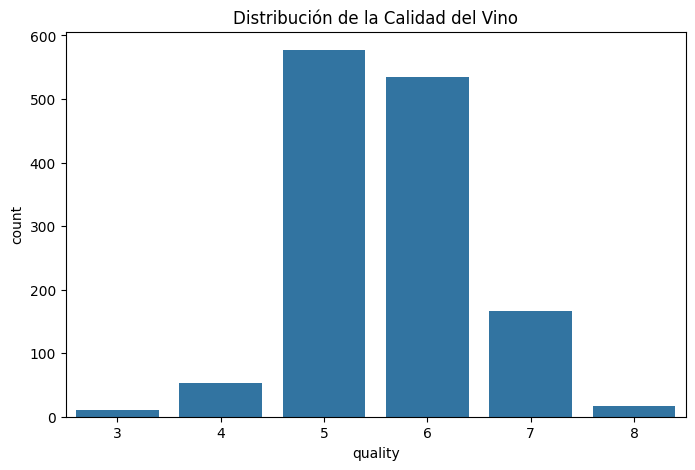

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df)
plt.title('Distribución de la Calidad del Vino')

### Discretización

Agrupo los valores de la columna `quality` en tres categorías distintas definidos por los rangos.

In [9]:
df['type_quality'] = pd.cut(
    df['quality'], 
    bins=(0, 4, 6, 10), 
    labels=(0, 1, 2), 
    right=True,
    include_lowest=True
)

#Me aseguro de que la variable sea de tipo Int
df['type_quality'] = df['type_quality'].astype(int)

### Visualización `type_quality`

Text(0, 0.5, 'Conteo de Vinos')

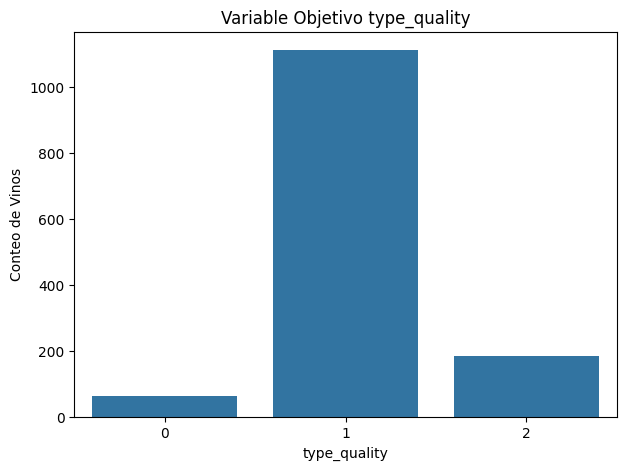

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(x='type_quality', data=df) 
plt.title('Variable Objetivo type_quality')
plt.xlabel('type_quality')
plt.ylabel('Conteo de Vinos')

In [11]:
df = df.drop('quality', axis=1)

#### Observaciones: 
> - Se puede observar como la relación de variables con el conteo se mantiene con la nueva columna `type_quality`, la cual agrupa los valores de la antigua columna `quality` en tres categorias que clasifican el vino según la calidad.
> - Ahora mi variable objetivo es `type_quality`


## Análisis de correlaciones

In [12]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'type_quality'],
      dtype='object')

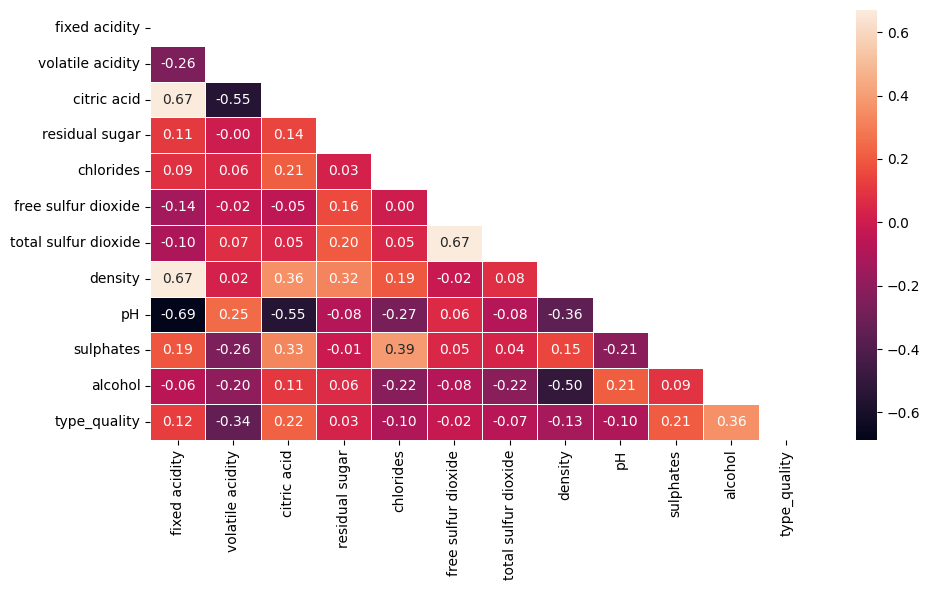

In [13]:
corr = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'type_quality']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

##### Observaciones:
 ##### Correlación con la variable objetivo `type_quality`
> - `alcohol` +0.36 Mejor predictor positivo. A mayor contenido de alcohol, mayor es la calidad.
> - `volatile acidity` -0.34 Mejor predictor negativo. A mayor acidez volátil (que suele indicar deterioro), menor es la calidad.
> - `sulphates` +0.21 Correlación positiva moderada.
> - `citric` acid +0.22 Correlación positiva moderada.
> - `density` -0.27Correlación negativa moderada.
> - `pH` -0.10 Correlación negativa muy débil.
> - `residual sugar` +0.03 Correlación muy cercana a cero; prácticamente no hay relación lineal con la calidad.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


## Split

In [15]:
X = df.drop('type_quality', axis=1)
y = df['type_quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18 )

X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
472,12.5,0.370,0.55,2.6,0.083,25.0,68.0,0.9995,3.15,0.82,10.4
25,6.3,0.390,0.16,1.4,0.080,11.0,23.0,0.9955,3.34,0.56,9.3
691,9.2,0.920,0.24,2.6,0.087,12.0,93.0,0.9998,3.48,0.54,9.8
240,8.9,0.635,0.37,1.7,0.263,5.0,62.0,0.9971,3.00,1.09,9.3
1218,8.2,0.400,0.31,1.9,0.082,8.0,24.0,0.9960,3.24,0.69,10.6


### Visualización 3D

In [16]:
fig = px.scatter_3d(df,
                    x='alcohol',
                    y='volatile acidity',
                    z='sulphates',
                    color="type_quality",
                    width=1000,
                    height=500,
                    color_discrete_sequence=["#FF0000", "#35D619", "#EAFF00"])
camera = dict(up=dict(x=1, y=3.5, z=0),
              eye=dict(x=2, y=0, z=0))

fig.update_layout(scene_camera=camera)

## Escalado de características

In [17]:
#Datos de entrenamiento escalados listos para SMOTE
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#convierto de vuelta a DataFrame para que SMOTE use nombres de columna.
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

Distribución original de las clases.

In [18]:
y_train.value_counts()

type_quality
1    886
2    152
0     49
Name: count, dtype: int64

In [19]:
smote = SMOTE(sampling_strategy='auto', random_state=18)

#SMOTE solo a los datos de entrenamiento.
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

Distribución de las clases después de SMOTE

In [20]:
y_train_balanced.value_counts()

type_quality
1    886
2    886
0    886
Name: count, dtype: int64

In [21]:
# Modelo
model = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(1, 50),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

# Entrenamiento
grid_search.fit(X_train_balanced, y_train_balanced)
best_model_knearest = grid_search.best_estimator_

best_params_knearest = grid_search.best_params_
best_params_knearest

{'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}

In [22]:
# Predicción
y_pred_test_knearest = best_model_knearest.predict(X_test_scaled_df)
y_pred_train_knearest = best_model_knearest.predict(X_train_balanced)

y_pred_test_knearest

array([1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2,
       1, 0, 1, 1, 2, 2, 1, 2, 1, 1, 0, 2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1, 2, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 0, 2, 0, 1,
       2, 0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 1, 1, 2, 2,
       1, 1, 1, 1, 2, 1, 1, 0, 2, 0, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 2, 2, 0, 1, 2, 1,
       0, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1,
       1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 0, 1, 0, 0, 0, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 0, 1, 2, 2])

In [23]:
print(classification_report(y_test, y_pred_test_knearest))

              precision    recall  f1-score   support

           0       0.12      0.21      0.15        14
           1       0.87      0.74      0.80       226
           2       0.32      0.53      0.40        32

    accuracy                           0.69       272
   macro avg       0.43      0.49      0.45       272
weighted avg       0.76      0.69      0.72       272



#### Observaciones:
> - El modelo es eficiente identificando la clase mayoritaria (1) con una precisión del 87%.
> - La peor precisión es para la clase (0) con una precisión del 12% y con una precisión del 32% para los vinos de alta calidad la clase (2)
> - Las diferencia que hay entre las precisiones de se debe al desbalance de clases.
> - El accuracy general del 69% es engañoso, ya que está inflado por el éxito en la clase 1.

#### Matriz de confusion

Text(70.72222222222221, 0.5, 'Realidad (Datos)')

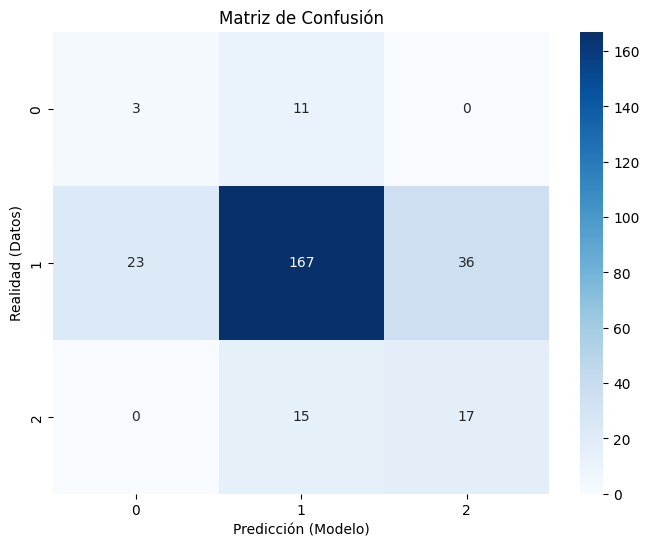

In [24]:
# Crear la matriz
cm = confusion_matrix(y_test, y_pred_test_knearest)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Datos)')

##### Observaciones:
> - Sesgo hacia la Clase Mayoritaria, el modelo demuestra una fuerte tendencia a predecir la clase 1, concentra el mayor número de aciertos (167).
> - Deficiencia discriminatoria de la clase 0, el modelo logra 3 aciertos frente a 11 erroneamente clasificados en la clase 1.
> - El modelo confunde casi la misma cantidad de instancias de las que acierta, 17 aciertos y 15 falsos positivos.

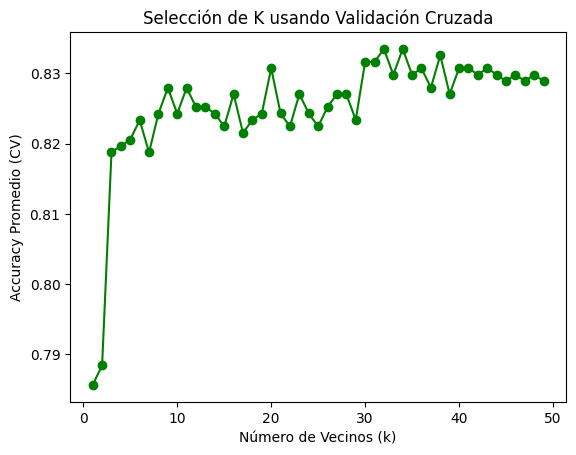

In [25]:
k_values = range(1, 50)
cv_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_accuracies.append(scores.mean())

plt.plot(k_values, cv_accuracies, marker='o', color='green')
plt.title('Selección de K usando Validación Cruzada')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Accuracy Promedio (CV)')
plt.show()

## Función predict_wine_quality

In [ ]:
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol']

def predict_wine_quality(fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
                         chlorides, free_sulfur_dioxide, total_sulfur_dioxide, 
                         density, pH, sulphates, alcohol):
    

    # Crear un DataFrame con una sola fila para la predicción
    input_data = pd.DataFrame([[
        fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
        chlorides, free_sulfur_dioxide, total_sulfur_dioxide, 
        density, pH, sulphates, alcohol
    ]], columns=features)
    
    # Realizar la predicción
    prediction = best_model_knearest.predict(input_data)
    
    return prediction[0]


# Ingresar valores numéricos de las características del vino para predecir su calidad.
predict_wine_quality(7.2, 0.3, 0.35, 1.5, 0.08, 15, 45, 0.996, 3.3, 0.6, 11.5)

np.int64(2)

#### Observaciones:
> -  El modelo identifica al vino como a uno de la categoria (2) dentro de `type_quality`.

In [27]:
with open('../models/nearest-neighbours-model.pkl', 'wb') as file:
    pickle.dump(best_model_knearest, file)

##### Conclusiones:
> - SMOTE puede generar muestras sintéticas que invaden el espacio de la clase mayoritaria.
> Consecuencia: Esto aumenta el ruido en el conjunto de entrenamiento. Cuando entrenO el K-Neighbors Classifier con estos datos ruidosos, el modelo aprende límites de decisión confusos. Al evaluar en el conjunto de prueba (que no tiene ese ruido), el modelo falla y la precisión cae.
#### IMPORTANTE: Smote no es la mejor via para este proyecto